# Capstone Project: Feature Sets A, B, and C - Comparison and Conclusions

Predicting Diabetes Risk from Health Survey Data: A Machine Learning Approach for Early Diabetes Prevention

This notebook brings together the modelling results from:

- `CDM Feature A Modelling.ipynb` - original features only (21 predictors)
- `CDM Feature B Modeling.ipynb` - original features plus engineered features (27 predictors)
- `CDM Feature C Modelling.ipynb` - reduced EDA-driven feature set (14 predictors)

The main goal of this comparison is to answer three questions:

1. Which model performs best for diabetes screening when recall and false negatives matter most?
2. Did feature engineering (Set B) improve results over the original variables (Set A)?
3. Did a smaller feature set (Set C) maintain performance while simplifying the model?

For this project, recall and false negatives are the priority metrics. Missing someone at risk of diabetes is worse than incorrectly flagging them for further screening.


## 1. Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = r"c:\Users\Conno\Data Science Course\Capstone"

METRIC_COLS = [
    "Training Accuracy",
    "Test Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC AUC",
    "False Positives",
    "False Negatives",
]

FEATURE_SET_INFO = {
    "A": "All original cleaned BRFSS variables (21 predictors)",
    "B": "Original variables plus engineered features (27 predictors)",
    "C": "Reduced EDA subset with strongest relationships (14 predictors)",
}

MODEL_NAME_MAP = {
    "Balanced Bagging Model": "Balanced Bagging",
    "Balanced Random Trees": "Balanced Random Forest",
}

CORE_MODELS = [
    "Logistic Regression",
    "Linear SVM",
    "RBF SVM",
    "Balanced Bagging",
    "Stacking Classifier",
    "Voting Classifier",
    "Gaussian Naive Bayes",
]

IMBALANCED_MODELS = ["Easy Ensemble", "Balanced Random Forest"]

## 2. Load and Combine Results

Results are loaded from CSV files exported at the end of each modelling notebook. If you re-run a modelling notebook and save a new CSV, re-run this section to refresh the comparison.


In [2]:
results_a = pd.read_csv(DATA_DIR + "\\all_model_results_a.csv")
results_b = pd.read_csv(DATA_DIR + "\\all_model_results_b.csv")
results_c = pd.read_csv(DATA_DIR + "\\all_model_results_c.csv")

results_a["Feature Set"] = "A"
results_b["Feature Set"] = "B"
results_c["Feature Set"] = "C"

all_results = pd.concat([results_a, results_b, results_c], ignore_index=True)

if "Balanced Accuracy" in all_results.columns:
    all_results = all_results.drop(columns=["Balanced Accuracy"])

all_results["Model"] = all_results["Model"].replace(MODEL_NAME_MAP)

before = len(all_results)
all_results = all_results.sort_values(["Feature Set", "Model"])
all_results = all_results.drop_duplicates(subset=["Feature Set", "Model"], keep="last")
all_results = all_results.reset_index(drop=True)

print("Loaded", before, "rows, kept", len(all_results), "after removing duplicates")

if len(all_results) != 27:
    print("Warning: expected 27 model runs (9 models x 3 feature sets).")

for col in METRIC_COLS:
    all_results[col] = pd.to_numeric(all_results[col], errors="coerce")

all_results.head()

Loaded 27 rows, kept 27 after removing duplicates


,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
1,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
2,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
4,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058


## 3. Feature Set Overview


In [3]:
rows = []

for fs in ["A", "B", "C"]:
    n_models = len(all_results[all_results["Feature Set"] == fs])
    if fs == "A":
        n_features = 21
    elif fs == "B":
        n_features = 27
    else:
        n_features = 14

    rows.append({
        "Feature Set": fs,
        "Number of Predictors": n_features,
        "Description": FEATURE_SET_INFO[fs],
        "Models Tested": n_models,
    })

feature_overview = pd.DataFrame(rows)
feature_overview

,Feature Set,Number of Predictors,Description,Models Tested
0,A,21,All original cleaned BRFSS variables (21 predi...,9
1,B,27,Original variables plus engineered features (2...,9
2,C,14,Reduced EDA subset with strongest relationship...,9


## 4. Full Results Table

Sorted by Feature Set, then by recall (highest first) and false negatives (lowest first).


In [4]:
full_table = all_results.sort_values(
    by=["Feature Set", "Recall", "False Negatives"],
    ascending=[True, False, True],
)
full_table = full_table.reset_index(drop=True)

full_table.round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,A,Easy Ensemble,0.7251,0.1529,0.1529,1.0000,0.2653,0.7312,48595,0
1,A,Balanced Random Forest,0.8949,0.3001,0.1755,0.9669,0.2971,0.6804,39863,290
2,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978
3,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984
4,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058
5,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106
6,A,Stacking Classifier,0.7880,0.7231,0.3242,0.7473,0.4522,0.8116,13668,2217
7,A,Voting Classifier,0.8304,0.7673,0.3503,0.6098,0.4450,0.8022,9923,3424
8,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711
9,B,Easy Ensemble,0.7183,0.2646,0.1703,0.9836,0.2903,0.7414,42045,144


## 5. Practical Models vs High-Recall / High-False-Positive Models

Some imbalanced-learning models (Easy Ensemble, Balanced Random Forest) achieve very high recall but produce too many false positives to be practical for screening. I flag these separately so the comparison focuses on models that balance sensitivity with usability.


In [5]:
FP_THRESHOLD = 20000
labels = []
for fp in all_results["False Positives"]:
    if fp > FP_THRESHOLD:
        labels.append("No - too many false positives")
    else:
        labels.append("Yes")

all_results["Practical for Screening"] = labels

practical = all_results[all_results["Practical for Screening"] == "Yes"].copy()

print("Practical models:", len(practical), "of", len(all_results), "total runs")
practical.sort_values(by=["Feature Set", "Recall"], ascending=[True, False]).round(4)

Practical models: 21 of 27 total runs


,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives,Practical for Screening
6,A,RBF SVM,0.7268,0.7048,0.3124,0.7746,0.4453,0.8034,14955,1978,Yes
0,A,Balanced Bagging,0.7258,0.7124,0.3187,0.7739,0.4514,0.8139,14517,1984,Yes
4,A,Linear SVM,0.7136,0.7115,0.3166,0.7654,0.4480,0.8097,14494,2058,Yes
5,A,Logistic Regression,0.7173,0.7151,0.3190,0.7600,0.4493,0.8099,14237,2106,Yes
7,A,Stacking Classifier,0.7880,0.7231,0.3242,0.7473,0.4522,0.8116,13668,2217,Yes
8,A,Voting Classifier,0.8304,0.7673,0.3503,0.6098,0.4450,0.8022,9923,3424,Yes
3,A,Gaussian Naive Bayes,0.7557,0.7559,0.3297,0.5770,0.4196,0.7697,10294,3711,Yes
9,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978,Yes
13,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033,Yes
15,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037,Yes


## 6. Best Model per Feature Set

Best = highest recall among practical models, with false negatives as the tie-breaker.


In [6]:
sorted_practical = practical.sort_values(
    by=["Feature Set", "Recall", "False Negatives"],
    ascending=[True, False, True],
)

best_rows = []
for feature_set in ["A", "B", "C"]:
    subset = sorted_practical[sorted_practical["Feature Set"] == feature_set]
    best_row = subset.iloc[0]
    best_rows.append(best_row)

best_per_set = pd.DataFrame(best_rows)

best_per_set = best_per_set[[
    "Feature Set",
    "Model",
    "Test Accuracy",
    "Recall",
    "F1-score",
    "ROC AUC",
    "False Positives",
    "False Negatives",
]]

best_per_set.round(4)

,Feature Set,Model,Test Accuracy,Recall,F1-score,ROC AUC,False Positives,False Negatives
6,A,RBF SVM,0.7048,0.7746,0.4453,0.8034,14955,1978
9,B,Balanced Bagging,0.7083,0.7746,0.4482,0.8107,14758,1978
24,C,RBF SVM,0.6994,0.7760,0.4412,0.7984,15281,1965


## 7. Visual Comparisons


### 7.1 Recall by Model and Feature Set (practical models only)


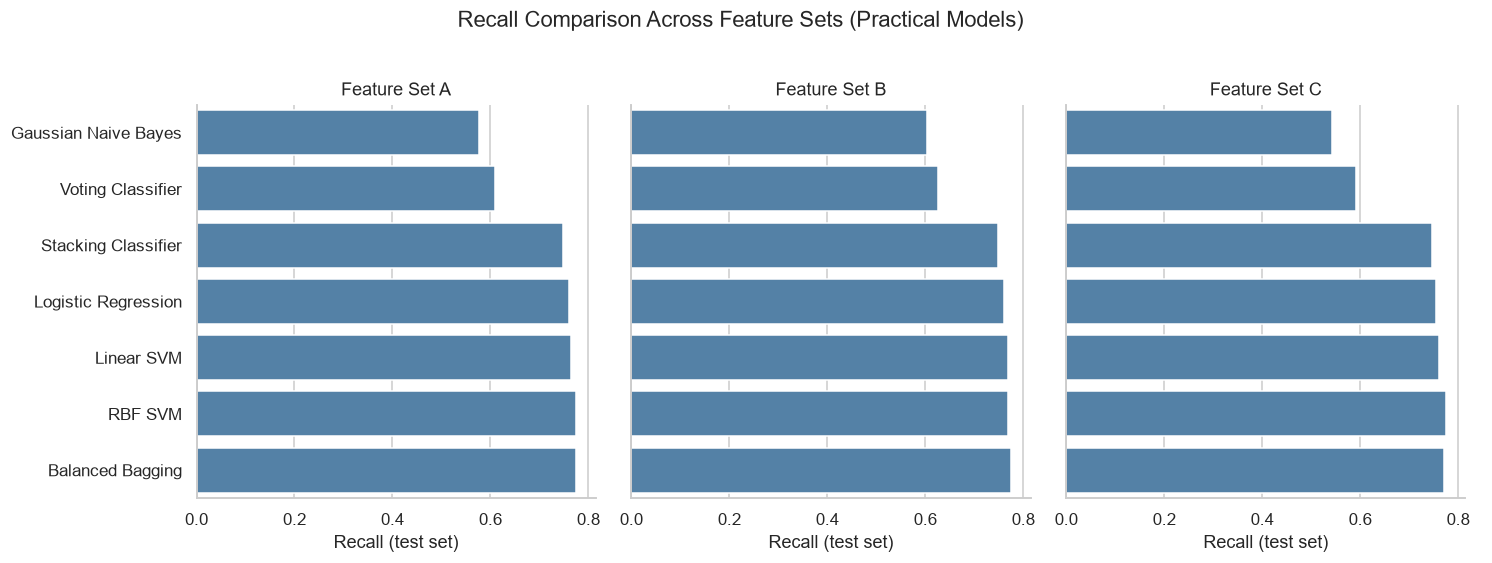

In [7]:
plot_df = practical[practical["Model"].isin(CORE_MODELS)].copy()
plot_df = plot_df.sort_values("Recall", ascending=True)

g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="Recall",
    y="Model",
    col="Feature Set",
    col_order=["A", "B", "C"],
    height=5,
    aspect=0.9,
    color="steelblue",
)

g.set_titles("Feature Set {col_name}")
g.set_xlabels("Recall (test set)")
g.set_ylabels("")
plt.suptitle("Recall Comparison Across Feature Sets (Practical Models)", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 False Negatives by Model and Feature Set


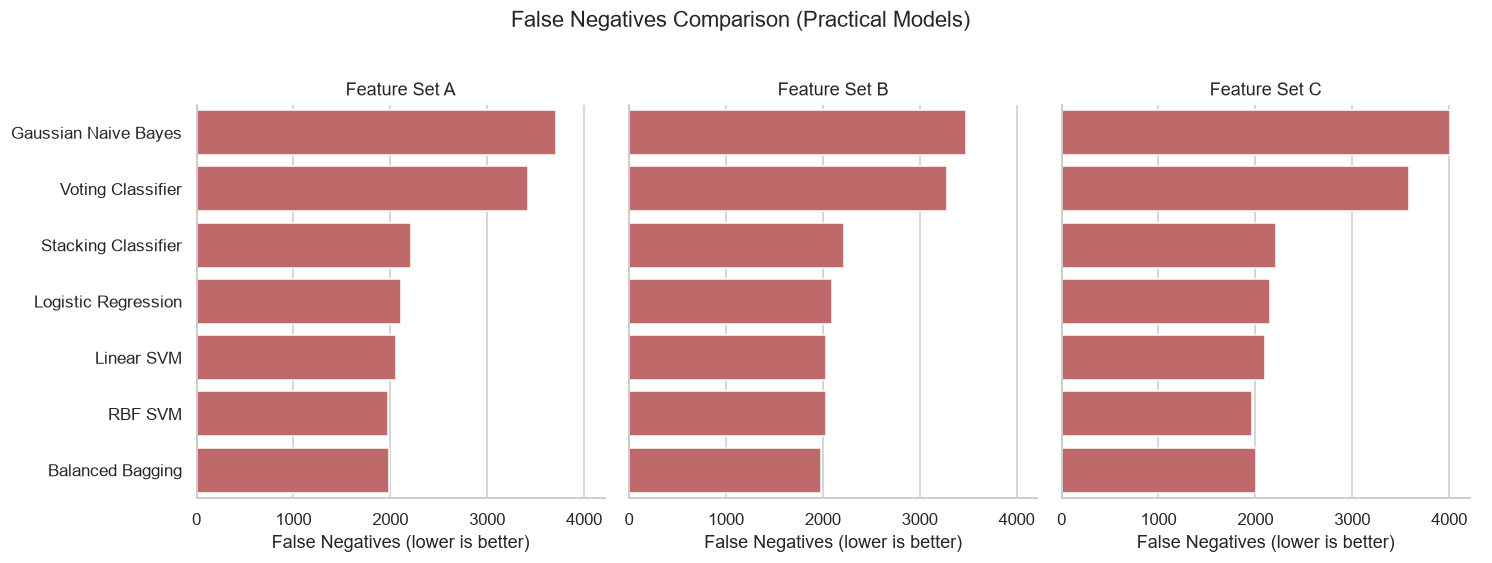

In [8]:
fn_df = practical[practical["Model"].isin(CORE_MODELS)].copy()
fn_df = fn_df.sort_values("False Negatives", ascending=False)

g = sns.catplot(
    data=fn_df,
    kind="bar",
    x="False Negatives",
    y="Model",
    col="Feature Set",
    col_order=["A", "B", "C"],
    height=5,
    aspect=0.9,
    color="indianred",
)

g.set_titles("Feature Set {col_name}")
g.set_xlabels("False Negatives (lower is better)")
g.set_ylabels("")
plt.suptitle("False Negatives Comparison (Practical Models)", y=1.02)
plt.tight_layout()
plt.show()

### 7.3 Heatmap: Recall Across Feature Sets and Models


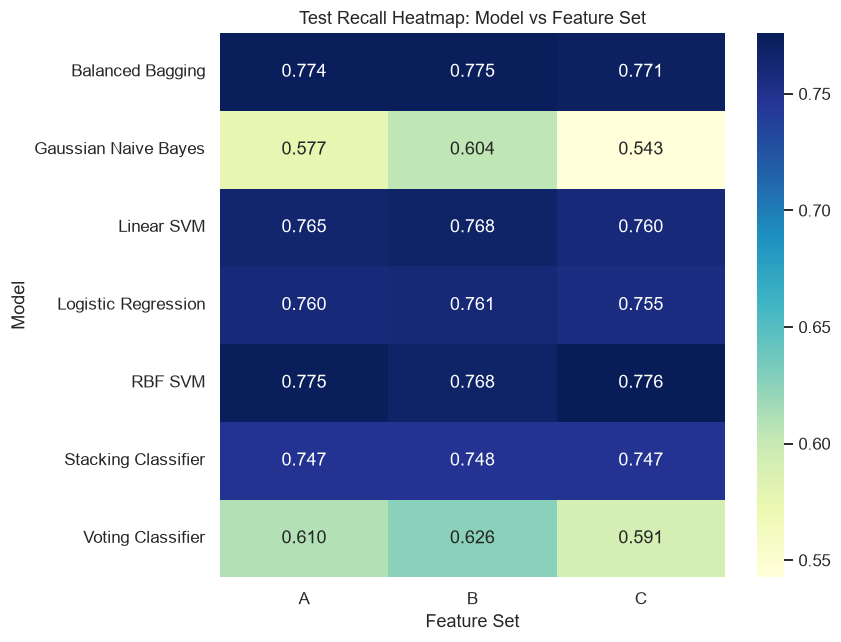

In [9]:
temp = practical[practical["Model"].isin(CORE_MODELS)].copy()

recall_table = temp.pivot_table(
    index="Model",
    columns="Feature Set",
    values="Recall",
    aggfunc="mean",
)

recall_table = recall_table[["A", "B", "C"]]

plt.figure(figsize=(8, 6))
sns.heatmap(recall_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Test Recall Heatmap: Model vs Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### 7.4 Recall vs Precision Trade-off


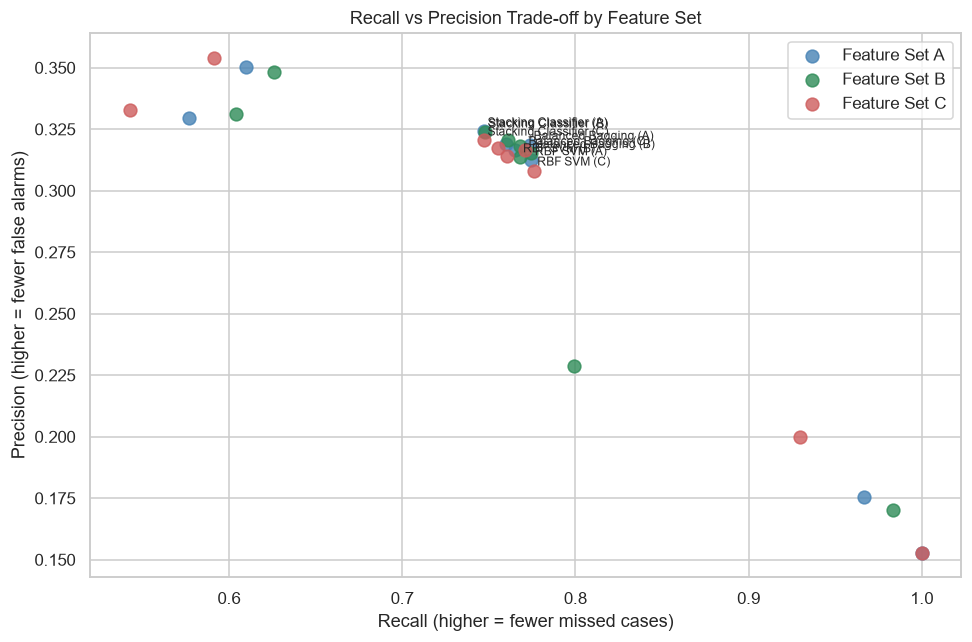

In [10]:
models_to_plot = CORE_MODELS + IMBALANCED_MODELS
scatter_df = all_results[all_results["Model"].isin(models_to_plot)].copy()

plt.figure(figsize=(9, 6))

colors = {"A": "steelblue", "B": "seagreen", "C": "indianred"}

for fs in ["A", "B", "C"]:
    subset = scatter_df[scatter_df["Feature Set"] == fs]
    plt.scatter(
        subset["Recall"],
        subset["Precision"],
        label="Feature Set " + fs,
        color=colors[fs],
        s=70,
        alpha=0.8,
    )

important_models = ["RBF SVM", "Balanced Bagging", "Stacking Classifier"]
for i in range(len(scatter_df)):
    row = scatter_df.iloc[i]
    if row["Model"] in important_models:
        label = row["Model"] + " (" + row["Feature Set"] + ")"
        plt.text(row["Recall"] + 0.002, row["Precision"] + 0.002, label, fontsize=8)

plt.xlabel("Recall (higher = fewer missed cases)")
plt.ylabel("Precision (higher = fewer false alarms)")
plt.title("Recall vs Precision Trade-off by Feature Set")
plt.legend()
plt.tight_layout()
plt.show()

### 7.5 ROC AUC Comparison (core models)


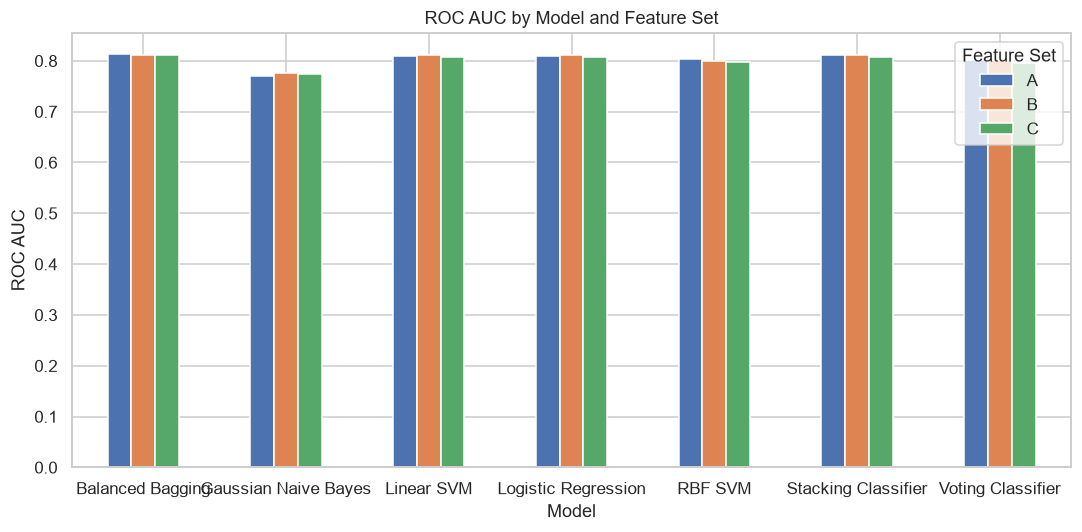

In [11]:
temp = practical[practical["Model"].isin(CORE_MODELS)].copy()

roc_table = temp.pivot_table(
    index="Model",
    columns="Feature Set",
    values="ROC AUC",
    aggfunc="mean",
)
roc_table = roc_table[["A", "B", "C"]]

roc_table.plot(kind="bar", figsize=(10, 5))
plt.title("ROC AUC by Model and Feature Set")
plt.xlabel("Model")
plt.ylabel("ROC AUC")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.6 Cross-Feature Comparison (Models Across Sets A, B, C)

One chart comparing Feature Sets A, B, and C for each practical model on:

- recall (higher is better)
- false negatives (lower is better)
- test accuracy (higher is better)

The dashed orange line marks the overall winner on recall and false negatives: RBF SVM on Feature Set C (recall 0.776, 1,965 FN). Accuracy is shown for context because higher-accuracy models did not always minimise missed cases.


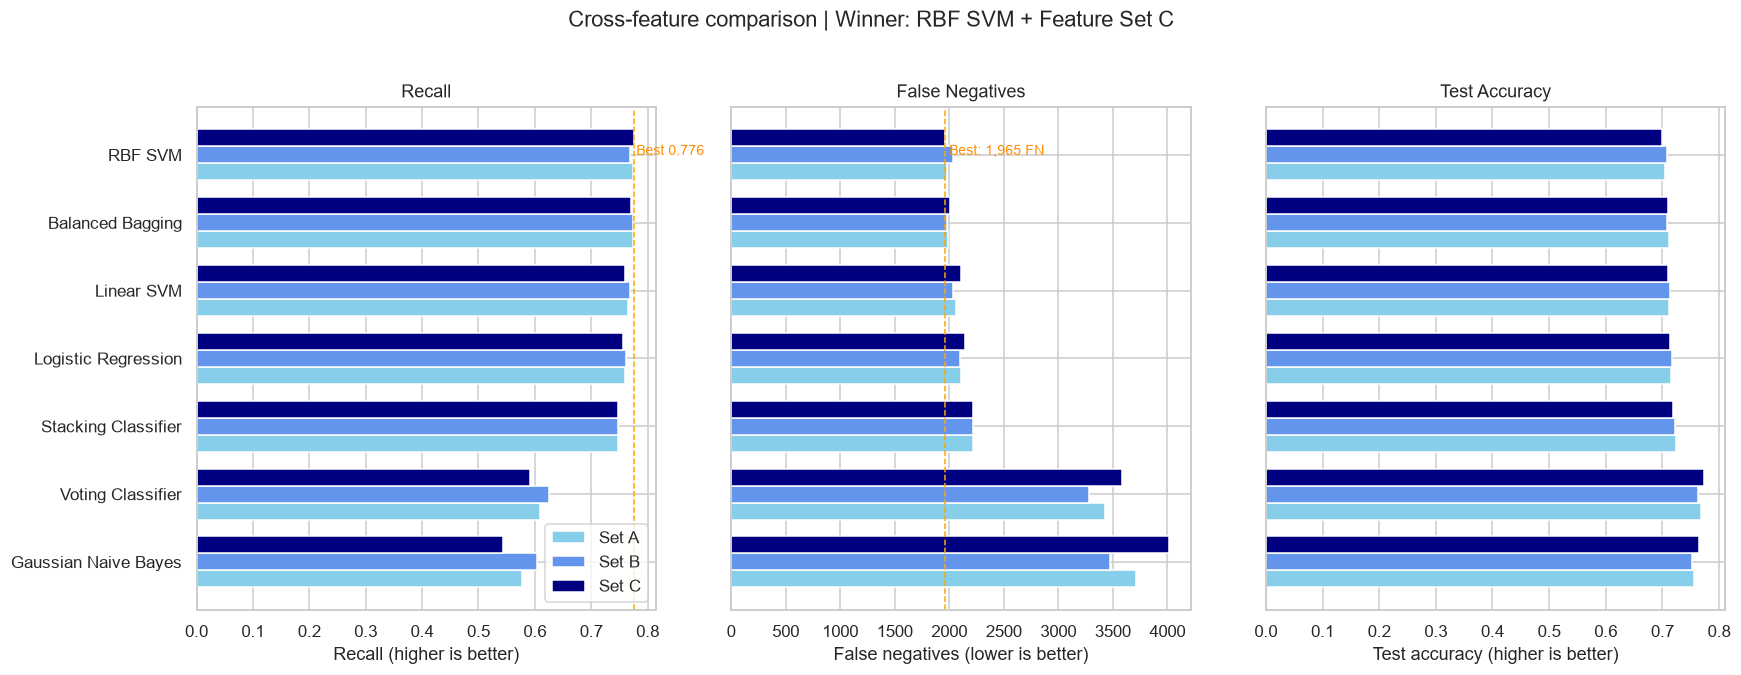

In [12]:
plot_models = []
for m in CORE_MODELS:
    if m in list(practical["Model"]):
        plot_models.append(m)

c_rows = practical[practical["Feature Set"] == "C"]
c_order = c_rows.sort_values("Recall", ascending=True)
plot_models = []
for m in c_order["Model"]:
    if m in CORE_MODELS:
        plot_models.append(m)

colors = {"A": "skyblue", "B": "cornflowerblue", "C": "navy"}
y_pos = np.arange(len(plot_models))
bar_height = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

# Panel 1: Recall
ax = axes[0]
for i, fs in enumerate(["A", "B", "C"]):
    values = []
    for m in plot_models:
        row = practical[(practical["Model"] == m) & (practical["Feature Set"] == fs)]
        values.append(float(row["Recall"].iloc[0]))
    ax.barh(y_pos + (i - 1) * bar_height, values, height=bar_height, label="Set " + fs, color=colors[fs])
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_models)
ax.set_xlabel("Recall (higher is better)")
ax.set_title("Recall")
ax.axvline(0.776, color="orange", linestyle="--", linewidth=1)
ax.text(0.78, len(plot_models) - 1, "Best 0.776", color="darkorange", fontsize=9)

ax = axes[1]
for i, fs in enumerate(["A", "B", "C"]):
    values = []
    for m in plot_models:
        row = practical[(practical["Model"] == m) & (practical["Feature Set"] == fs)]
        values.append(float(row["False Negatives"].iloc[0]))
    ax.barh(y_pos + (i - 1) * bar_height, values, height=bar_height, label="Set " + fs, color=colors[fs])
ax.set_xlabel("False negatives (lower is better)")
ax.set_title("False Negatives")
ax.axvline(1965, color="orange", linestyle="--", linewidth=1)
ax.text(2000, len(plot_models) - 1, "Best: 1,965 FN", color="darkorange", fontsize=9)

ax = axes[2]
for i, fs in enumerate(["A", "B", "C"]):
    values = []
    for m in plot_models:
        row = practical[(practical["Model"] == m) & (practical["Feature Set"] == fs)]
        values.append(float(row["Test Accuracy"].iloc[0]))
    ax.barh(y_pos + (i - 1) * bar_height, values, height=bar_height, label="Set " + fs, color=colors[fs])
ax.set_xlabel("Test accuracy (higher is better)")
ax.set_title("Test Accuracy")

axes[0].legend(loc="lower right")
fig.suptitle("Cross-feature comparison | Winner: RBF SVM + Feature Set C", y=1.02)
plt.tight_layout()
plt.show()

## 8. Side-by-Side Comparison: Core Models Across Feature Sets


In [13]:
compare_metrics = ["Recall", "False Negatives", "Test Accuracy", "ROC AUC", "F1-score"]

temp = practical[practical["Model"].isin(CORE_MODELS)].copy()

core_compare = temp.pivot_table(
    index="Model",
    columns="Feature Set",
    values=compare_metrics,
    aggfunc="mean",
)

core_compare.round(4)

F1-score                 False Negatives                  \
Feature Set                 A       B       C               A       B       C   
Model                                                                           
Balanced Bagging       0.4514  0.4482  0.4487          1984.0  1978.0  2009.0   
Gaussian Naive Bayes   0.4196  0.4279  0.4125          3711.0  3474.0  4013.0   
Linear SVM             0.4480  0.4498  0.4447          2058.0  2033.0  2103.0   
Logistic Regression    0.4493  0.4512  0.4468          2106.0  2094.0  2146.0   
RBF SVM                0.4453  0.4453  0.4412          1978.0  2037.0  1965.0   
Stacking Classifier    0.4522  0.4518  0.4485          2217.0  2214.0  2217.0   
Voting Classifier      0.4450  0.4473  0.4429          3424.0  3284.0  3586.0   

                     ROC AUC                  Recall                  \
Feature Set                A       B       C       A       B       C   
Model                                                                  
Balanced Bagging      0.8139  0.8107  0.8116  0.7739  0.7746  0.7710   
Gaussian Naive Bayes  0.7697  0.7767  0.7741  0.5770  0.6041  0.5426   
Linear SVM            0.8097  0.8114  0.8067  0.7654  0.7683  0.7603   
Logistic Regression   0.8099  0.8115  0.8070  0.7600  0.7613  0.7554   
RBF SVM               0.8034  0.7998  0.7984  0.7746  0.7678  0.7760   
Stacking Classifier   0.8116  0.8119  0.8079  0.7473  0.7477  0.7473   
Voting Classifier     0.8022  0.8017  0.7967  0.6098  0.6257  0.5913   

                     Test Accuracy                  
Feature Set                      A       B       C  
Model                                               
Balanced Bagging            0.7124  0.7083  0.7103  
Gaussian Naive Bayes        0.7559  0.7530  0.7637  
Linear SVM                  0.7115  0.7125  0.7096  
Logistic Regression         0.7151  0.7168  0.7139  
RBF SVM                     0.7048  0.7074  0.6994  
Stacking Classifier         0.7231  0.7226  0.7190  
Voting Classifier           0.7673  0.7635  0.7725

## 9. Did Feature Engineering or Feature Reduction Help?

This section compares the same model across all three feature sets to see whether Set B (engineered) or Set C (reduced) changed performance.


In [14]:
impact_rows = []

for model in CORE_MODELS:
    subset = practical[practical["Model"] == model]

    row_a = subset[subset["Feature Set"] == "A"]
    row_b = subset[subset["Feature Set"] == "B"]
    row_c = subset[subset["Feature Set"] == "C"]

    if len(row_a) == 0 or len(row_b) == 0 or len(row_c) == 0:
        continue

    recall_a = float(row_a["Recall"].iloc[0])
    recall_b = float(row_b["Recall"].iloc[0])
    recall_c = float(row_c["Recall"].iloc[0])

    if recall_a >= recall_b and recall_a >= recall_c:
        best_set = "A"
    elif recall_b >= recall_c:
        best_set = "B"
    else:
        best_set = "C"

    impact_rows.append({
        "Model": model,
        "Recall A": recall_a,
        "Recall B": recall_b,
        "Recall C": recall_c,
        "FN A": int(row_a["False Negatives"].iloc[0]),
        "FN B": int(row_b["False Negatives"].iloc[0]),
        "FN C": int(row_c["False Negatives"].iloc[0]),
        "Best Feature Set (Recall)": best_set,
        "Recall change B vs A": round(recall_b - recall_a, 4),
        "Recall change C vs A": round(recall_c - recall_a, 4),
    })

feature_impact = pd.DataFrame(impact_rows)
feature_impact

,Model,Recall A,Recall B,Recall C,FN A,FN B,FN C,Best Feature Set (Recall),Recall change B vs A,Recall change C vs A
0,Logistic Regression,0.7600,0.7613,0.7554,2106,2094,2146,B,0.0013,-0.0046
1,Linear SVM,0.7654,0.7683,0.7603,2058,2033,2103,B,0.0029,-0.0051
2,RBF SVM,0.7746,0.7678,0.7760,1978,2037,1965,C,-0.0068,0.0014
3,Balanced Bagging,0.7739,0.7746,0.7710,1984,1978,2009,B,0.0007,-0.0029
4,Stacking Classifier,0.7473,0.7477,0.7473,2217,2214,2217,B,0.0004,0.0000
5,Voting Classifier,0.6098,0.6257,0.5913,3424,3284,3586,B,0.0159,-0.0185
6,Gaussian Naive Bayes,0.5770,0.6041,0.5426,3711,3474,4013,B,0.0271,-0.0344


## 10. Overall Rankings

Rank all practical model runs by recall first, then by false negatives.


In [15]:
rankings = practical.sort_values(
    by=["Recall", "False Negatives"],
    ascending=[False, True],
)
rankings = rankings.reset_index(drop=True)
rankings["Rank"] = rankings.index + 1

rankings = rankings[[
    "Rank",
    "Feature Set",
    "Model",
    "Recall",
    "False Negatives",
    "Test Accuracy",
    "ROC AUC",
    "F1-score",
]]

rankings.head(15).round(4)

,Rank,Feature Set,Model,Recall,False Negatives,Test Accuracy,ROC AUC,F1-score
0,1,C,RBF SVM,0.7760,1965,0.6994,0.7984,0.4412
1,2,A,RBF SVM,0.7746,1978,0.7048,0.8034,0.4453
2,3,B,Balanced Bagging,0.7746,1978,0.7083,0.8107,0.4482
3,4,A,Balanced Bagging,0.7739,1984,0.7124,0.8139,0.4514
4,5,C,Balanced Bagging,0.7710,2009,0.7103,0.8116,0.4487
5,6,B,Linear SVM,0.7683,2033,0.7125,0.8114,0.4498
6,7,B,RBF SVM,0.7678,2037,0.7074,0.7998,0.4453
7,8,A,Linear SVM,0.7654,2058,0.7115,0.8097,0.4480
8,9,B,Logistic Regression,0.7613,2094,0.7168,0.8115,0.4512
9,10,C,Linear SVM,0.7603,2103,0.7096,0.8067,0.4447


## 11. Conclusions and Final Recommendation


### 11.1 Feature Set Comparison

| Feature Set | Predictors | Best Practical Model | Best Recall | False Negatives | Key Finding |
|---|---:|---|---:|---:|---|
| A | 21 | RBF SVM (Balanced Bagging very close) | 0.775 | 1,978 | Strong baseline with original variables alone |
| B | 27 | Balanced Bagging | 0.775 | 1,978 | Engineered features did not clearly beat Set A |
| C | 14 | RBF SVM | 0.776 | 1,965 | Smaller set held up well; RBF SVM edged ahead on recall |

### 11.2 Model Comparison (across all feature sets)

Best for minimising missed cases (recall-focused screening):

- RBF SVM on Feature Set C: recall 0.776, 1,965 false negatives
- Balanced Bagging on Feature Sets A and B: recall about 0.774, 1,978 false negatives
- These models consistently outperformed logistic regression and Linear SVM on recall

Best for overall balance (recall + precision + ROC AUC):

- Stacking Classifier across all three sets: recall about 0.747, highest ROC AUC among ensembles (0.808 to 0.812)
- Logistic regression and Linear SVM: competitive, interpretable, and close to the top models

Models that look good on accuracy but fail the screening goal:

- Voting Classifier: highest test accuracy (about 0.76 to 0.77) but recall drops to about 0.59 to 0.63, missing 3,300+ cases
- Gaussian Naive Bayes: high accuracy (about 0.75 to 0.76) but recall only about 0.54 to 0.60

Models with extreme recall but impractical false positives:

- Easy Ensemble and Balanced Random Forest: recall above 0.93 but tens of thousands of false positives

### 11.3 Did Feature Engineering Help?

Feature Set B added clinically motivated engineered variables (BMI categories, `overall_health_burden`, `risk_factor_count`, and related features). Across the core models, the differences between Set A and Set B were small (typically within 0.005 to 0.01 on recall). This suggests the original BRFSS variables already captured most of the predictive signal, and the engineered features did not produce a meaningful improvement for this screening objective.

### 11.4 Did Feature Reduction Help?

Feature Set C used only 14 EDA-selected predictors. Performance was similar to Sets A and B for most models. RBF SVM on Set C achieved the best recall in the entire project (0.776, 1,965 FN). This shows that a smaller, interpretable feature set can perform as well as, or slightly better than, the full feature sets, which is useful for deployment.

### 11.5 Final Recommendation

For a diabetes screening tool where the priority is catching at-risk individuals:

1. Recommended model: RBF SVM trained on Feature Set C (or Balanced Bagging on Set A or B as a close alternative)
2. Why: Highest recall (0.776) with the fewest false negatives (1,965) among practical models, using only 14 predictors
3. Trade-off: Lower precision (about 0.31) means more people flagged for follow-up screening, which is acceptable when the cost of a missed case is high
4. If interpretability matters more: logistic regression on any feature set provides competitive recall (about 0.76) with a simpler, explainable model
5. If overall balance matters more: Stacking Classifier offers the best ensemble trade-off across recall, F1, and ROC AUC

### 11.6 Limitations and Next Steps

- All models were evaluated on the same held-out test split (25%, random state 42) from the BRFSS 2015 dataset
- RBF SVM and some ensemble models were trained on a 20k subsample for speed; linear models used the full training set
- Threshold tuning (for example lowering the classification threshold to boost recall further) was not explored
- External validation on a different year or population would strengthen the conclusions
- For deployment, I would pair the chosen model with clear clinical follow-up pathways for flagged individuals


### 11.7 Production and Deployment Path

A realistic deployment path for the recommended RBF SVM on Feature Set C would be:

1. Batch scoring pipeline - annual or periodic of cleaned BRFSS-style survey data, apply the same preprocessing and feature list (14 predictors), score with the saved model artefact
2. Human-in-the-loop review - route high-risk flags to nurses or GPs for confirmatory testing (HbA1c, fasting glucose), not automatic diagnosis
3. Monitoring - track recall, false positive rate, and score distributions over time; retrain when new BRFSS waves arrive or drift is detected
4. Governance - document limitations (self-reported data, merged prediabetes/diabetes class, no external validation yet)

A minimal reproducible training pattern using `sklearn.pipeline.Pipeline` is shown in the feature engineering notebook (scaler plus model in one object) to support consistent production preprocessing.

## 12. Export Combined Results


In [16]:
output_path = DATA_DIR + "\\all_model_results_combined.csv"
all_results.to_csv(output_path, index=False)
print("Saved:", output_path)
print("Total rows:", len(all_results))

Saved: c:\Users\Conno\Data Science Course\Capstone\all_model_results_combined.csv
Total rows: 27
